# CAN-GRU-AE — Metrics

Evaluate a model trained with:

```bash
cd "Python scripts"
python -m datasets.can.preprocess
python -m datasets.can.preprocess --include-attacks
python -m experiments.train --dataset can --model can_gru --epochs 20
```

This notebook:
1. Loads the trained `can_gru` bundle + training scaler
2. Builds message windows from **engineered** HCRL parquet (Chowdhury FE)
3. Scores **real** attack traces (DoS / Fuzzy / RPM / gear) against held-out normal traffic
4. Reports PR AUC, macro F1, AUROC, recall/FPR, per-attack breakdown, streaming latency

> Run with cwd = `Python scripts/` (or rely on the path bootstrap in the next cells).
> Requires: `numpy pandas pyarrow scikit-learn matplotlib "jax[cpu]"`

## 1. Configuration

Point these at your trained bundle and processed CAN parquet directory.

In [1]:
from pathlib import Path

# Bundle produced by: python -m experiments.train --dataset can --model can_gru
BUNDLE_DIR = Path("experiments/checkpoints/can")
NAME = "can_gru_can"  # trainer default: {model}_{dataset}

# Engineered parquet dir (normal.parquet + optional dos/fuzzy/rpm/gear.parquet)
PROCESSED_DIR = Path("../Data/CAN/processed")

# Cap windows per source for interactive eval speed
MAX_BENIGN_WINDOWS = 10_000
MAX_ATTACK_WINDOWS_PER_KIND = 5_000

# Attack parquet stems written by `python -m datasets.can.preprocess --include-attacks`
ATTACK_KINDS = ("dos", "fuzzy", "rpm", "gear")

SEED = 42
FIGURES_DIR = Path("experiments/figures/can")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports & load the trained bundle

In [2]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

# Bootstrap so the notebook works from experiments/notebooks/ or Python scripts/
_HERE = Path.cwd().resolve()
for candidate in (_HERE, _HERE.parent, _HERE.parent.parent):
    if (candidate / "ids_core").is_dir() and (candidate / "models").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        SCRIPTS = candidate
        break
else:
    raise SystemExit("Could not find Python scripts/ (ids_core + models) on path")

from ids_core.data import flatten_windows, make_windows
from ids_core.profiles import get_profile
from models.can_gru import CANGRUAutoencoder
from models.can_gru.features import FEATURES, N_RAW_FEATURES

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

profile = get_profile("can")
BUNDLE_DIR = (SCRIPTS / BUNDLE_DIR).resolve() if not BUNDLE_DIR.is_absolute() else BUNDLE_DIR
PROCESSED_DIR = (
    (SCRIPTS / PROCESSED_DIR).resolve() if not Path(PROCESSED_DIR).is_absolute() else Path(PROCESSED_DIR)
)
FIGURES_DIR = (SCRIPTS / FIGURES_DIR).resolve() if not FIGURES_DIR.is_absolute() else FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

meta_path = BUNDLE_DIR / f"{NAME}_meta.json"
scaler_path = BUNDLE_DIR / f"{NAME}_scaler.npz"
ckpt_path = BUNDLE_DIR / f"{NAME}.npz"
for p in (ckpt_path, scaler_path):
    if not p.is_file():
        raise FileNotFoundError(
            f"Missing {p}. Train first:\n"
            f"  python -m experiments.train --dataset can --model can_gru --epochs 20"
        )

meta = json.loads(meta_path.read_text()) if meta_path.is_file() else {}
WINDOW = int(meta.get("window_size", profile.window_size))
STRIDE = int(meta.get("stride", profile.stride))

scaler = np.load(scaler_path)
MU = scaler["mean"].astype(np.float32)
SD = scaler["std"].astype(np.float32)
SD = np.where(SD > 1e-6, SD, 1.0).astype(np.float32)

model = CANGRUAutoencoder(
    n_features=N_RAW_FEATURES,
    window_size=WINDOW,
    checkpoint_dir=BUNDLE_DIR,
)
model.restore_checkpoint(NAME)

n_params = int(sum(np.prod(np.array(v).shape) for v in model.params.values()))
print(f"Loaded bundle: {BUNDLE_DIR} ({NAME})")
print(f"  features     : {N_RAW_FEATURES}  window={WINDOW}  stride={STRIDE}")
print(f"  parameters   : {n_params:,}")
print(f"  threshold    : {model.threshold:.6f}")
print(f"  processed    : {PROCESSED_DIR}")

[Model] restored: /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/experiments/checkpoints/can/can_gru_can.npz
Loaded bundle: /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/experiments/checkpoints/can (can_gru_can)
  features     : 23  window=50  stride=50
  parameters   : 34,036
  threshold    : 1.527948
  processed    : /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/CAN/processed


## 3. Load engineered parquet & build windows

Windows use the **training** mean/std so the calibrated threshold stays valid.
A window is labeled attack if **any** frame inside it has `is_anomaly=1`.

If attack parquets are missing, run:

```bash
python -m datasets.can.preprocess --include-attacks
```

In [3]:
def load_engineered(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    missing = [c for c in FEATURES if c not in df.columns]
    if missing:
        raise SystemExit(f"{path.name} missing columns: {missing}")
    if "is_anomaly" not in df.columns:
        df["is_anomaly"] = 0
    return df


def windows_from_df(
    df: pd.DataFrame,
    *,
    max_windows: int | None = None,
    force_label: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    feats = df.loc[:, list(FEATURES)].to_numpy(dtype=np.float32)
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
    norm = ((feats - MU) / SD).astype(np.float32)
    row_labels = df["is_anomaly"].to_numpy(dtype=np.int8)
    w, y, _ = make_windows(norm, stride=STRIDE, window=WINDOW, labels=row_labels)
    if force_label is not None and len(y):
        y = np.full(len(y), force_label, dtype=np.int8)
    if max_windows is not None and len(w) > max_windows:
        idx = np.linspace(0, len(w) - 1, max_windows, dtype=int)
        w, y = w[idx], y[idx]
    return w, y


normal_path = PROCESSED_DIR / "normal.parquet"
if not normal_path.is_file():
    raise FileNotFoundError(
        f"Missing {normal_path}. Run: python -m datasets.can.preprocess"
    )

normal_df = load_engineered(normal_path)
benign_w, benign_y = windows_from_df(
    normal_df, max_windows=MAX_BENIGN_WINDOWS, force_label=0
)
print(f"[Benign] {normal_path.name}: rows={len(normal_df):,}  windows={len(benign_w):,}")

attack_parts = []
kind_parts = []
for kind in ATTACK_KINDS:
    path = PROCESSED_DIR / f"{kind}.parquet"
    if not path.is_file():
        print(f"[Skip] missing {path.name} — run preprocess --include-attacks")
        continue
    df = load_engineered(path)
    # Keep windows that contain at least one injected/attack frame when labels exist;
    # otherwise treat the whole attack file as positive.
    w, y = windows_from_df(df, max_windows=MAX_ATTACK_WINDOWS_PER_KIND)
    if (df["is_anomaly"] == 1).any():
        keep = y == 1
        w, y = w[keep], y[keep]
    else:
        y = np.ones(len(w), dtype=np.int8)
    print(f"[Attack] {path.name}: rows={len(df):,}  attack_windows={len(w):,}")
    if len(w):
        attack_parts.append(w)
        kind_parts.append(np.full(len(w), kind, dtype=object))

if not attack_parts:
    raise SystemExit(
        "No attack parquet found. Run:\n"
        "  python -m datasets.can.preprocess --include-attacks"
    )

attack_w = np.concatenate(attack_parts, axis=0)
attack_kinds = np.concatenate(kind_parts, axis=0)
attack_y = np.ones(len(attack_w), dtype=np.int8)

windows = np.concatenate([benign_w, attack_w], axis=0)
labels = np.concatenate(
    [np.zeros(len(benign_w), dtype=np.int8), attack_y], axis=0
)
kinds = np.concatenate(
    [np.full(len(benign_w), "benign", dtype=object), attack_kinds], axis=0
)

# Shuffle for latency timing / display only (metrics are label-based)
perm = rng.permutation(len(windows))
windows, labels, kinds = windows[perm], labels[perm], kinds[perm]

prevalence = float(labels.mean())
print(
    "[Test]",
    f"benign={int((labels == 0).sum()):,}",
    f"attack={int((labels == 1).sum()):,}",
    f"prevalence={prevalence:.3f}",
)
print(
    "[Attacks]",
    ", ".join(f"{k}={int((kinds == k).sum())}" for k in ATTACK_KINDS if (kinds == k).any()),
)

[Benign] normal.parquet: rows=988,871  windows=10,000
[Attack] dos.parquet: rows=3,665,771  attack_windows=1,494
[Attack] fuzzy.parquet: rows=3,838,860  attack_windows=1,688
[Attack] rpm.parquet: rows=4,621,702  attack_windows=2,242
[Attack] gear.parquet: rows=4,443,142  attack_windows=2,137
[Test] benign=10,000 attack=7,561 prevalence=0.431
[Attacks] dos=1494, fuzzy=1688, rpm=2242, gear=2137


## 4. Score windows (reconstruction head)

Score = per-window reconstruction MSE after the ID-bit embedding + GRU decode.
Prediction uses the calibrated training threshold.

In [4]:
flat = flatten_windows(windows)
recon_scores = model.reconstruction_errors(flat)
recon_pred = (recon_scores > model.threshold).astype(int)

HEADS = {
    "Reconstruction": (recon_scores, recon_pred, float(model.threshold)),
}
print(f"scored {len(windows):,} windows  threshold={model.threshold:.6f}")

scored 17,561 windows  threshold=1.527948


## 5. Detection latency & footprint

Streaming protocol (same as sibling notebooks / `mvp_v1`): score **one window per call**,
then report **p50 / p99** after a short JIT warm-up.

parameters            : 34,036
approx float32 size   : 133.0 KiB
latency (n=2,000)  : p50=133.3µs  p99=178.9µs


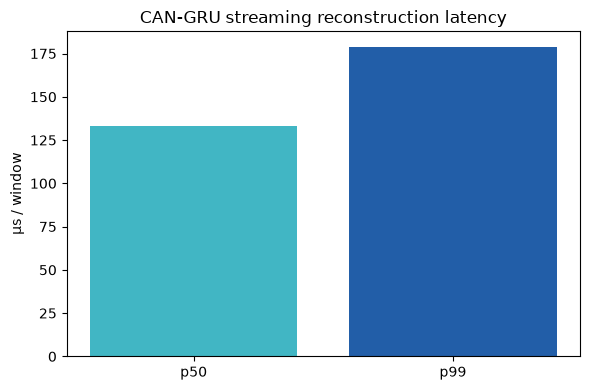

In [5]:
# Warm up JIT on a small batch of flats
_ = model.reconstruction_errors(flat[: min(64, len(flat))])

n_lat = min(len(flat), 2000)
lat_us = np.empty(n_lat, dtype=np.float32)
for i in range(n_lat):
    t0 = time.perf_counter()
    model.reconstruction_error(flat[i])
    lat_us[i] = (time.perf_counter() - t0) * 1e6

lat_p50 = float(np.percentile(lat_us, 50))
lat_p99 = float(np.percentile(lat_us, 99))
size_kb = n_params * 4 / 1024

print(f"parameters            : {n_params:,}")
print(f"approx float32 size   : {size_kb:.1f} KiB")
print(f"latency (n={n_lat:,})  : p50={lat_p50:.1f}µs  p99={lat_p99:.1f}µs")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["p50", "p99"], [lat_p50, lat_p99], color=["#41b6c4", "#225ea8"])
ax.set_ylabel("µs / window")
ax.set_title("CAN-GRU streaming reconstruction latency")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "can_gru_latency.png", dpi=120)
plt.show()

## 6. Headline metrics (PR AUC + macro F1)

In [6]:
rows = []
for name, (scores, pred, thr) in HEADS.items():
    rows.append({
        "head": name,
        "PR AUC": average_precision_score(labels, scores),
        "macro F1": f1_score(labels, pred, average="macro", zero_division=0),
        "AUROC": roc_auc_score(labels, scores),
        "recall": float(pred[labels == 1].mean()) if (labels == 1).any() else float("nan"),
        "FPR": float(pred[labels == 0].mean()) if (labels == 0).any() else float("nan"),
        "threshold": thr,
        "latency p50 (µs)": lat_p50,
        "latency p99 (µs)": lat_p99,
        "params": n_params,
    })
summary = pd.DataFrame(rows).set_index("head")
print(f"random-baseline PR AUC = prevalence = {prevalence:.3f}\n")
display(summary.round(3))
summary.to_csv(FIGURES_DIR / "can_gru_summary.csv")

random-baseline PR AUC = prevalence = 0.431



,PR AUC,macro F1,AUROC,recall,FPR,threshold,latency p50 (µs),latency p99 (µs),params
head,,,,,,,,,
Reconstruction,0.653,0.577,0.569,0.238,0.007,1.528,133.333,178.881,34036


## 7. Precision–Recall curve

PR AUC (average precision) is the primary metric for imbalanced detection.
The dashed line is the random baseline (= attack prevalence).

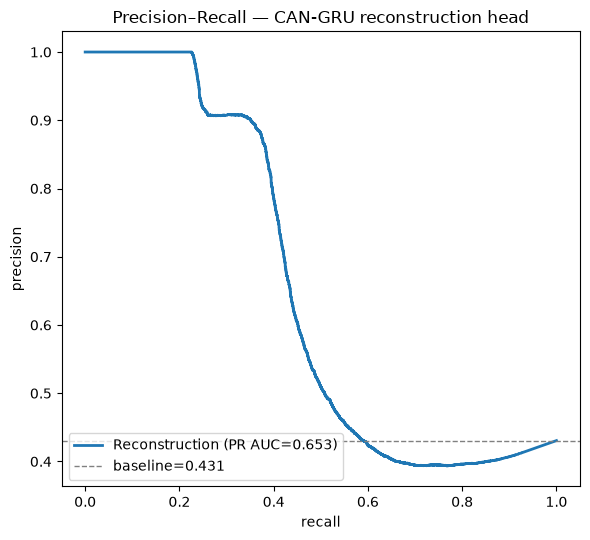

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, (scores, pred, thr) in HEADS.items():
    prec, rec, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    ax.plot(rec, prec, lw=2, label=f"{name} (PR AUC={ap:.3f})")
ax.axhline(prevalence, ls="--", color="gray", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision–Recall — CAN-GRU reconstruction head")
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "can_gru_pr_curve.png", dpi=120)
plt.show()

## 8. Score distribution (benign vs attack)

Red dashed line = calibrated reconstruction threshold from training.

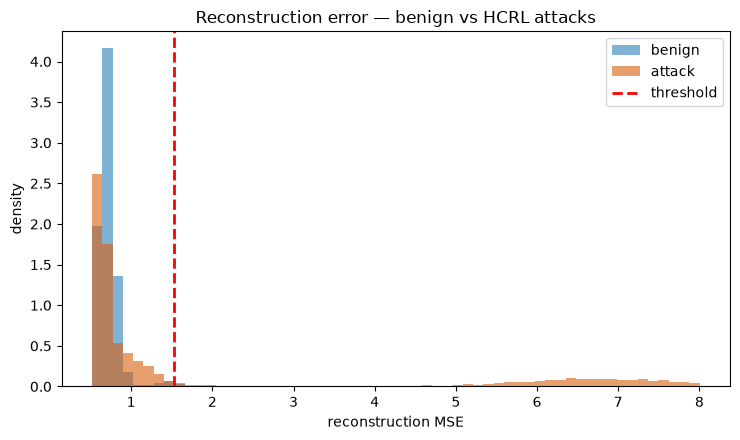

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
scores, pred, thr = HEADS["Reconstruction"]
b = scores[labels == 0]
a = scores[labels == 1]
lo, hi = np.percentile(scores, 1), np.percentile(scores, 99)
bins = np.linspace(lo, hi, 60)
ax.hist(b, bins=bins, alpha=0.6, density=True, color="#2c7fb8", label="benign")
ax.hist(a, bins=bins, alpha=0.6, density=True, color="#d95f0e", label="attack")
ax.axvline(thr, color="red", ls="--", lw=2, label="threshold")
ax.set_title("Reconstruction error — benign vs HCRL attacks")
ax.set_xlabel("reconstruction MSE")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "can_gru_score_hist.png", dpi=120)
plt.show()

## 9. Per-attack PR AUC (each family vs benign)

Threshold-independent — how detectable each HCRL attack family is against benign traffic.

,n_windows,PR AUC,score_mean
attack,,,
dos,1494,0.618,1.072
fuzzy,1688,1.000,6.747
rpm,2242,0.144,0.860
gear,2137,0.107,0.618


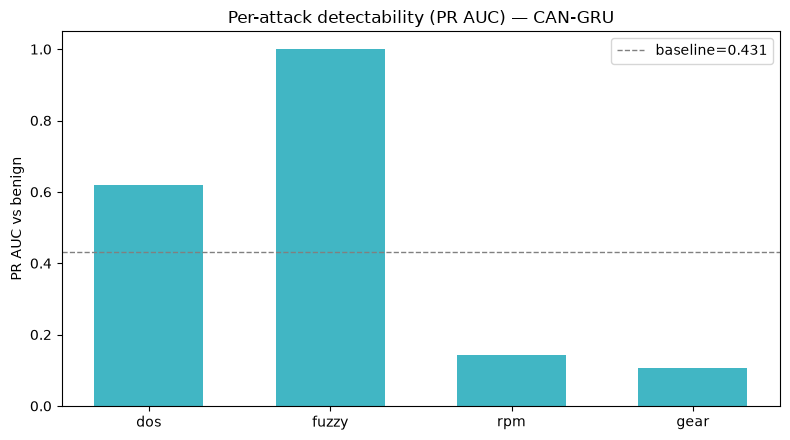

In [9]:
rows = []
benign_s = recon_scores[labels == 0]
for k in ATTACK_KINDS:
    m = (kinds == k) & (labels == 1)
    if not m.any():
        continue
    y = np.concatenate([np.zeros(len(benign_s)), np.ones(int(m.sum()))])
    s = np.concatenate([benign_s, recon_scores[m]])
    rows.append({
        "attack": k,
        "n_windows": int(m.sum()),
        "PR AUC": average_precision_score(y, s),
        "score_mean": float(recon_scores[m].mean()),
    })

per_attack = pd.DataFrame(rows).set_index("attack")
display(per_attack.round(3))

x = np.arange(len(per_attack))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x, per_attack["PR AUC"], 0.6, color="#41b6c4")
ax.axhline(prevalence, color="gray", ls="--", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xticks(x, per_attack.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("PR AUC vs benign")
ax.set_title("Per-attack detectability (PR AUC) — CAN-GRU")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "can_gru_per_attack.png", dpi=120)
plt.show()

per_attack.to_csv(FIGURES_DIR / "can_gru_per_attack.csv")

## 10. Reading the results

- **PR AUC / macro F1** — primary metrics for this imbalanced setting. PR AUC well above
  the prevalence baseline means reconstruction error ranks attacks above benign frames.
- **recall / FPR** — at the calibrated training threshold. Tune via `--safety-mult` at train time.
- **Per-attack PR AUC** — DoS (ID `0x000` floods) and Fuzzy (random ID/payload) usually separate
  cleanly via ID-bit + temporal features; spoofing (RPM / gear) can be subtler.
- **Latency p50 / p99** — streaming, one window per call (edge-relevant).

Figures / CSVs are written to `experiments/figures/can/`.